In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [ ]:
file_path = "../Dataset_04/test.csv"
try:
    data = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    raise FileNotFoundError(f"The file at {file_path} was not found.")

Dataset loaded successfully.


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    800000 non-null  int64  
 1   Age                   787511 non-null  float64
 2   Gender                800000 non-null  object 
 3   Annual Income         770140 non-null  float64
 4   Marital Status        787664 non-null  object 
 5   Number of Dependents  726870 non-null  float64
 6   Education Level       800000 non-null  object 
 7   Occupation            560875 non-null  object 
 8   Health Score          750551 non-null  float64
 9   Location              800000 non-null  object 
 10  Policy Type           800000 non-null  object 
 11  Previous Claims       557198 non-null  float64
 12  Vehicle Age           799997 non-null  float64
 13  Credit Score          708549 non-null  float64
 14  Insurance Duration    799998 non-null  float64
 15  

In [ ]:
data.head()

<marimo-table data-initial-value='[]' data-label='null' data-data='"./@file/1079-157416-Q2FoLx9r.csv"' data-total-rows='5' data-total-columns='20' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["id", ["integer", "int64"]], ["Age", ["number", "float64"]], ["Gender", ["string", "object"]], ["Annual Income", ["number", "float64"]], ["Marital Status", ["string", "object"]], ["Number of Dependents", ["number", "float64"]], ["Education Level", ["string", "object"]], ["Occupation", ["string", "object"]], ["Health Score", ["number", "float64"]], ["Location", ["string", "object"]], ["Policy Type", ["string", "object"]], ["Previous Claims", ["number", "float64"]], ["Vehicle Age", ["number", "float64"]], ["Credit Score", ["number", "float64"]], ["Insurance Duration", ["number", "float64"]], ["Policy Start Date", ["string", "object"]], ["Customer Feedback", ["string", "object"]], ["Smoking Status", ["string", "object"]], ["Exercise Frequency", ["string", "object"]], ["Property Type", ["string", "object"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-row-headers='[]'>

In [ ]:
data.describe(include="all")

<marimo-table data-initial-value='[]' data-label='null' data-data='"./@file/1342-157416-CxRF688T.csv"' data-total-rows='11' data-total-columns='20' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["id", ["number", "float64"]], ["Age", ["number", "float64"]], ["Gender", ["string", "object"]], ["Annual Income", ["number", "float64"]], ["Marital Status", ["string", "object"]], ["Number of Dependents", ["number", "float64"]], ["Education Level", ["string", "object"]], ["Occupation", ["string", "object"]], ["Health Score", ["number", "float64"]], ["Location", ["string", "object"]], ["Policy Type", ["string", "object"]], ["Previous Claims", ["number", "float64"]], ["Vehicle Age", ["number", "float64"]], ["Credit Score", ["number", "float64"]], ["Insurance Duration", ["number", "float64"]], ["Policy Start Date", ["string", "object"]], ["Customer Feedback", ["string", "object"]], ["Smoking Status", ["string", "object"]], ["Exercise Frequency", ["string", "object"]], ["Property Type", ["string", "object"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-row-headers='[""]'>

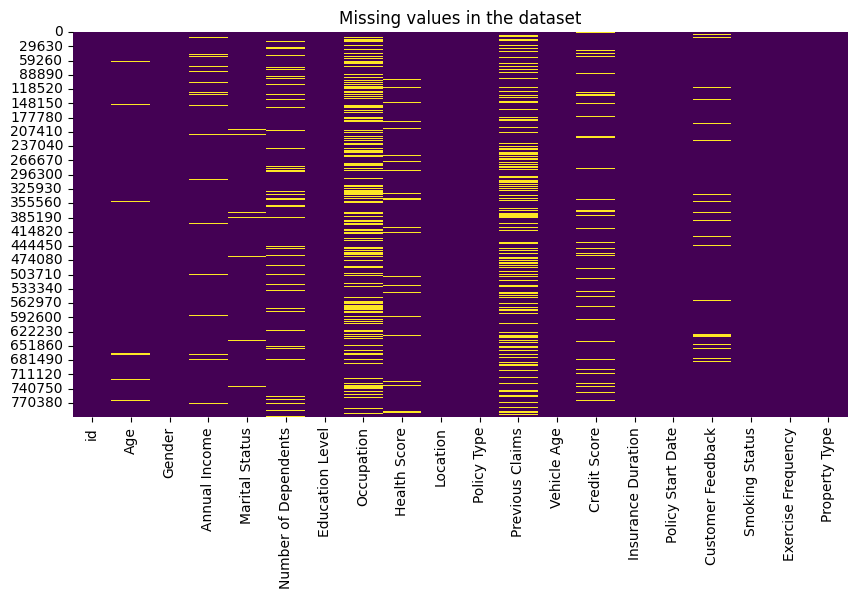

In [ ]:
missing_mask = data.isnull()
plt.figure(figsize=(10, 5))
sns.heatmap(missing_mask, cbar=False, cmap="viridis")
plt.title("Missing values in the dataset")
plt.show()

In [ ]:
for missing in data.columns:
    missing_values = data[missing].isnull().sum()
    if missing_values > 0:
        print(f"Column {missing} has {missing_values} missing values.")

Column Age has 12489 missing values.
Column Annual Income has 29860 missing values.


Column Marital Status has 12336 missing values.
Column Number of Dependents has 73130 missing values.


Column Occupation has 239125 missing values.
Column Health Score has 49449 missing values.


Column Previous Claims has 242802 missing values.
Column Vehicle Age has 3 missing values.
Column Credit Score has 91451 missing values.
Column Insurance Duration has 2 missing values.


Column Customer Feedback has 52276 missing values.


In [ ]:
label_encoder = LabelEncoder()
categorical_columns = [
    "Gender",
    "Marital Status",
    "Education Level",
    "Occupation",
    "Location",
    "Policy Type",
    "Customer Feedback",
    "Smoking Status",
    "Exercise Frequency",
    "Property Type",
]
for column in categorical_columns:
    if column in data.columns:
        data[column] = label_encoder.fit_transform(data[column])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    800000 non-null  int64  
 1   Age                   787511 non-null  float64
 2   Gender                800000 non-null  int64  
 3   Annual Income         770140 non-null  float64
 4   Marital Status        800000 non-null  int64  
 5   Number of Dependents  726870 non-null  float64
 6   Education Level       800000 non-null  int64  
 7   Occupation            800000 non-null  int64  
 8   Health Score          750551 non-null  float64
 9   Location              800000 non-null  int64  
 10  Policy Type           800000 non-null  int64  
 11  Previous Claims       557198 non-null  float64
 12  Vehicle Age           799997 non-null  float64
 13  Credit Score          708549 non-null  float64
 14  Insurance Duration    799998 non-null  float64
 15  

In [ ]:
if "Policy Start Date" in data.columns:
    data["Policy Start Date"] = pd.to_datetime(data["Policy Start Date"])
    data["Policy Start Date"] = data["Policy Start Date"].astype("int64")
else:
    print("Column 'Policy Start Date' does not exist.")

correlation_matrix = data.corr()
correlation_matrix

<marimo-table data-initial-value='[]' data-label='null' data-data='"./@file/4679-157416-O185byzk.csv"' data-total-rows='20' data-total-columns='20' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["id", ["number", "float64"]], ["Age", ["number", "float64"]], ["Gender", ["number", "float64"]], ["Annual Income", ["number", "float64"]], ["Marital Status", ["number", "float64"]], ["Number of Dependents", ["number", "float64"]], ["Education Level", ["number", "float64"]], ["Occupation", ["number", "float64"]], ["Health Score", ["number", "float64"]], ["Location", ["number", "float64"]], ["Policy Type", ["number", "float64"]], ["Previous Claims", ["number", "float64"]], ["Vehicle Age", ["number", "float64"]], ["Credit Score", ["number", "float64"]], ["Insurance Duration", ["number", "float64"]], ["Policy Start Date", ["number", "float64"]], ["Customer Feedback", ["number", "float64"]], ["Smoking Status", ["number", "float64"]], ["Exercise Frequency", ["number", "float64"]], ["Property Type", ["number", "float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-row-headers='[""]'>

In [ ]:
data.isnull().sum()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
credit_score_target_column = "Credit Score"
credit_score_threshold = 0.0005

credit_score_correlation = correlation_matrix[credit_score_target_column]

credit_score_predictor_columns = [
    feature
    for feature in credit_score_correlation.index
    if abs(credit_score_correlation[feature]) > credit_score_threshold
]
credit_score_predictor_columns

In [ ]:
training_data_credit = data[data[credit_score_target_column].notnull()]
missing_data_credit = data[data[credit_score_target_column].isnull()]

x_full_credit = training_data_credit[credit_score_predictor_columns]
y_full_credit = training_data_credit[credit_score_target_column]

x_train_credit, x_val_credit, y_train_credit, y_val_credit = train_test_split(
    x_full_credit, y_full_credit, test_size=0.2, random_state=42
)

credit_score_model = RandomForestRegressor(random_state=42, n_estimators=100)
credit_score_model.fit(x_train_credit, y_train_credit)

y_val_credit_predictions = credit_score_model.predict(x_val_credit)

mae_credit = mean_absolute_error(y_val_credit, y_val_credit_predictions)
mse_credit = mean_squared_error(y_val_credit, y_val_credit_predictions)
r2_credit = r2_score(y_val_credit, y_val_credit_predictions)

print(f"Mean Absolute Error (MAE): {mae_credit}")
print(f"Mean Squared Error (MSE): {mse_credit}")
print(f"R-squared (R^2): {r2_credit}")

Mean Absolute Error (MAE): 0.0
Mean Squared Error (MSE): 0.0
R-squared (R^2): 1.0


In [ ]:
for q in y_val_credit_predictions:
    print(f"Predicted value: {q}")

In [ ]:
for r in data["Credit Score"]:
    print(f"Actual value: {r}")

In [ ]:
missing_data_preds_credit = credit_score_model.predict(
    missing_data_credit[credit_score_predictor_columns]
)
data.loc[
    data[credit_score_target_column].isnull(), credit_score_target_column
] = missing_data_preds_credit

In [ ]:
data.isnull().sum()

In [ ]:
age_target_column = "Age"
age_threshold = 0.0003

age_correlation = correlation_matrix[age_target_column]

age_predictor_columns = [
    feature
    for feature in age_correlation.index
    if abs(age_correlation[feature]) > age_threshold
]
age_predictor_columns

In [ ]:
training_data_age = data[data[age_target_column].notnull()]
missing_data_age = data[data[age_target_column].isnull()]

x_full_age = training_data_age[age_predictor_columns]
y_full_age = training_data_age[age_target_column]

x_train_age, x_val_age, y_train_age, y_val_age = train_test_split(
    x_full_age, y_full_age, test_size=0.2, random_state=42
)

age_model = RandomForestRegressor(random_state=42, n_estimators=100)
age_model.fit(x_train_age, y_train_age)

y_val_age_predictions = age_model.predict(x_val_age)

mae_age = mean_absolute_error(y_val_age, y_val_age_predictions)
mse_age = mean_squared_error(y_val_age, y_val_age_predictions)
r2_age = r2_score(y_val_age, y_val_age_predictions)

print(f"Mean Absolute Error (MAE): {mae_age}")
print(f"Mean Squared Error (MSE): {mse_age}")
print(f"R-squared (R^2): {r2_age}")

In [ ]:
for s in y_val_age_predictions:
    print(f"Predicted value: {s}")

In [ ]:
for t in data["Age"]:
    print(f"Actual value: {t}")

In [ ]:
missing_data_preds_age = age_model.predict(
    missing_data_age[age_predictor_columns]
)
data.loc[data[age_target_column].isnull(), age_target_column] = (
    missing_data_preds_age
)

In [ ]:
data.isnull().sum()

In [ ]:
target_column = "Annual Income"
threshold = 0.0005
target_correlation = correlation_matrix[target_column]
predictors = [
    feature
    for feature in target_correlation.index
    if abs(target_correlation[feature]) > threshold
]
predictors

In [ ]:
train_data = data[data[target_column].notnull()]
missing_data = data[data[target_column].isnull()]

x_train = train_data[predictors]
y_train = train_data[target_column]

x_train_set, x_val, y_train_set, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(x_train_set, y_train_set)

y_pred = model.predict(x_val)

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")

In [ ]:
missing_data_preds = model.predict(missing_data[predictors])
data.loc[data[target_column].isnull(), target_column] = missing_data_preds

In [ ]:
for u in y_pred:
    print(f"Predicted value: {u}")

In [ ]:
for v in data["Annual Income"]:
    print(f"Actual value: {v}")

In [ ]:
data.isnull().sum()

In [ ]:
health_score_target_column = "Health Score"
health_score_threshold = 0.0005

health_score_correlation = correlation_matrix[health_score_target_column]

health_score_predictor_columns = [
    feature
    for feature in health_score_correlation.index
    if abs(health_score_correlation[feature]) > health_score_threshold
]

health_score_predictor_columns

In [ ]:
training_data_health = data[data[health_score_target_column].notnull()]
missing_data_health = data[data[health_score_target_column].isnull()]

X_full_health = training_data_health[health_score_predictor_columns]
y_full_health = training_data_health[health_score_target_column]

X_train_health, X_val_health, y_train_health, y_val_health = train_test_split(
    X_full_health, y_full_health, test_size=0.2, random_state=42
)

health_score_model = RandomForestRegressor(random_state=42, n_estimators=100)
health_score_model.fit(X_train_health, y_train_health)

y_val_health_predictions = health_score_model.predict(X_val_health)

mae_health = mean_absolute_error(y_val_health, y_val_health_predictions)
mse_health = mean_squared_error(y_val_health, y_val_health_predictions)
r2_health = r2_score(y_val_health, y_val_health_predictions)

print(f"Mean Absolute Error (MAE): {mae_health}")
print(f"Mean Squared Error (MSE): {mse_health}")
print(f"R-squared (R^2): {r2_health}")

In [ ]:
for m in y_val_health_predictions:
    print(f"Predicted value: {m}")

In [ ]:
for n in data["Health Score"]:
    print(f"Actual value: {n}")

In [ ]:
missing_data_preds_health = health_score_model.predict(
    missing_data_health[health_score_predictor_columns]
)
data.loc[
    data[health_score_target_column].isnull(), health_score_target_column
] = missing_data_preds_health

In [ ]:
data.isnull().sum()

In [ ]:
dependents_target_column = "Number of Dependents"
dependents_threshold = 0.0005

dependents_correlation = correlation_matrix[dependents_target_column]

dependents_predictor_columns = [
    feature
    for feature in dependents_correlation.index
    if abs(dependents_correlation[feature]) > dependents_threshold
]

dependents_predictor_columns

In [ ]:
training_data_dependents = data[data[dependents_target_column].notnull()]
missing_data_dependents = data[data[dependents_target_column].isnull()]

X_full_dependents = training_data_dependents[dependents_predictor_columns]
y_full_dependents = training_data_dependents[dependents_target_column]

X_train_dependents, X_val_dependents, y_train_dependents, y_val_dependents = (
    train_test_split(
        X_full_dependents, y_full_dependents, test_size=0.2, random_state=42
    )
)

dependents_score_model = RandomForestRegressor(
    random_state=42, n_estimators=100
)
dependents_score_model.fit(X_train_dependents, y_train_dependents)

y_val_dependents_predictions = dependents_score_model.predict(X_val_dependents)

mae_dependents = mean_absolute_error(
    y_val_dependents, y_val_dependents_predictions
)
mse_dependents = mean_squared_error(
    y_val_dependents, y_val_dependents_predictions
)
r2_dependents = r2_score(y_val_dependents, y_val_dependents_predictions)

print(f"Mean Absolute Error (MAE): {mae_dependents}")
print(f"Mean Squared Error (MSE): {mse_dependents}")
print(f"R-squared (R^2): {r2_dependents}")

In [ ]:
for a in y_val_dependents_predictions:
    print(f"Predicted value: {a}")

In [ ]:
for b in data["Number of Dependents"]:
    print(f"Actual value: {b}")

In [ ]:
missing_data_preds_claims = claims_score_model.predict(
    missing_data_claims[previous_claims_predictor_columns]
)
data.loc[
    data[previous_claims_target_column].isnull(), previous_claims_target_column
] = missing_data_preds_claims

In [ ]:
data.isnull().sum()

In [ ]:
previous_claims_target_column = "Previous Claims"
previous_claims_threshold = 0.0005

previous_claims_correlation = correlation_matrix[previous_claims_target_column]

previous_claims_predictor_columns = [
    feature
    for feature in previous_claims_correlation.index
    if abs(previous_claims_correlation[feature]) > previous_claims_threshold
]

training_data_claims = data[data[previous_claims_target_column].notnull()]
missing_data_claims = data[data[previous_claims_target_column].isnull()]

X_full_claims = training_data_claims[previous_claims_predictor_columns]
y_full_claims = training_data_claims[previous_claims_target_column]

X_train_claims, X_val_claims, y_train_claims, y_val_claims = train_test_split(
    X_full_claims, y_full_claims, test_size=0.2, random_state=42
)

In [ ]:
claims_score_model = RandomForestRegressor(random_state=42, n_estimators=100)
claims_score_model.fit(X_train_claims, y_train_claims)

y_val_claims_predictions = claims_score_model.predict(X_val_claims)

mae_claims = mean_absolute_error(y_val_claims, y_val_claims_predictions)
mse_claims = mean_squared_error(y_val_claims, y_val_claims_predictions)
r2_claims = r2_score(y_val_claims, y_val_claims_predictions)

print(f"Mean Absolute Error (MAE): {mae_claims}")
print(f"Mean Squared Error (MSE): {mse_claims}")
print(f"R-squared (R^2): {r2_claims}")

In [ ]:
for c in y_val_claims_predictions:
    print(f"Predicted value: {c}")

In [ ]:
for d in data["Previous Claims"]:
    print(f"Actual value: {d}")

In [ ]:
missing_data_preds_dependents = dependents_score_model.predict(
    missing_data_dependents[dependents_predictor_columns]
)
data.loc[data[dependents_target_column].isnull(), dependents_target_column] = (
    missing_data_preds_dependents
)

In [ ]:
data.isnull().sum()

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
data["Vehicle Age"] = imputer.fit_transform(data[["Vehicle Age"]])

In [ ]:
imputer_insurance = KNNImputer(n_neighbors=3)
data["Insurance Duration"] = imputer_insurance.fit_transform(
    data[["Insurance Duration"]]
)

In [ ]:
data.isnull().sum()

In [ ]:
data.to_csv("../Dataset_04/test_cleaned.csv", index=False)

In [ ]:
cleand_data = pd.read_csv("../Dataset_04/test_cleaned.csv")
for e in cleand_data.columns:
    print(f"Column '{e}' has {cleand_data[e].isnull().sum()} missing values")